In [9]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("All libraries imported successfully!")

All libraries imported successfully!


In [10]:
# ============================================================
# STEP 2: UPLOAD AND LOAD SALES DATASET
# ============================================================

from google.colab import files

uploaded = files.upload()

print("File uploaded successfully!")

Saving Sales_Analysis_Dataset.xlsx to Sales_Analysis_Dataset (1).xlsx
File uploaded successfully!


In [11]:
# ============================================================
# LOAD THE SALES_DATA SHEET
# ============================================================

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name, sheet_name="Sales_Data")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully!
Shape: (5000, 22)

Columns:
['Order_ID', 'Order_Date', 'Customer_Name', 'Customer_Segment', 'Product_Name', 'Category', 'Sub_Category', 'Region', 'City', 'Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit', 'Payment_Method', 'Year', 'Month', 'Month_Number', 'Quarter', 'Profit_Margin', 'Unnamed: 20', 'Unnamed: 21']

First 5 rows:


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,City,Quantity,...,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin,Unnamed: 20,Unnamed: 21
0,ORD01158,2023-01-01,Kiara Desai,Corporate,Study Desk,Furniture,Tables,South,Kochi,8,...,1091.56,-44.55,Net Banking,2023,Jan,1,Q1,-4.08,NaN,2.475491e+06
1,ORD01837,2023-01-01,Neel Malhotra,Consumer,Samsung Galaxy A54,Technology,Phones,North,Jaipur,6,...,1641.60,17.95,Debit Card,2023,Jan,1,Q1,1.09,NaN,1.267235e+05
2,ORD03503,2023-01-01,Kabir Shah,Consumer,Ergonomic Office Chair,Furniture,Chairs,North,Amritsar,1,...,121.74,6.76,UPI,2023,Jan,1,Q1,5.55,NaN,1.537600e+04
3,ORD00744,2023-01-02,Rahul Verma,Consumer,Ball Pen Set,Office Supplies,Stationery,East,Guwahati,8,...,56.91,15.00,UPI,2023,Jan,1,Q1,26.36,NaN,5.000000e+03
4,ORD01221,2023-01-02,Diya Sharma,Corporate,Bookshelf,Furniture,Storage,North,Chandigarh,2,...,233.74,28.13,UPI,2023,Jan,1,Q1,12.03,NaN,4.950981e+02


In [12]:
# ============================================================
# STEP 4: DATASET INFORMATION AND INITIAL ANALYSIS
# ============================================================

print("Dataset Shape:")
print(df.shape)

print("\n" + "="*60)

print("Dataset Information:")
df.info()

print("\n" + "="*60)

print("Missing Values:")
print(df.isnull().sum())

print("\n" + "="*60)

print("Duplicate Rows:")
print(df.duplicated().sum())

print("\n" + "="*60)

print("Statistical Summary:")
display(df.describe())

print("\n" + "="*60)

print("First 5 Records:")
display(df.head())

Dataset Shape:
(5000, 22)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_ID          5000 non-null   object        
 1   Order_Date        5000 non-null   datetime64[ns]
 2   Customer_Name     5000 non-null   object        
 3   Customer_Segment  5000 non-null   object        
 4   Product_Name      5000 non-null   object        
 5   Category          5000 non-null   object        
 6   Sub_Category      5000 non-null   object        
 7   Region            5000 non-null   object        
 8   City              5000 non-null   object        
 9   Quantity          5000 non-null   int64         
 10  Unit_Price        5000 non-null   float64       
 11  Discount          5000 non-null   float64       
 12  Sales             5000 non-null   float64       
 13  Profit            5000 non-nul

,Order_Date,Quantity,Unit_Price,Discount,Sales,Profit,Year,Month_Number,Profit_Margin,Unnamed: 20,Unnamed: 21
count,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,1.0,6.000000e+00
mean,2024-07-06 18:40:36.480000,3.075200,181.014256,0.122810,495.098108,25.344700,2023.981000,6.92300,9.979708,0.0,4.371809e+05
min,2023-01-01 00:00:00,1.000000,5.580000,0.000000,3.940000,-391.590000,2023.000000,1.00000,-14.760000,0.0,5.119127e-02
25%,2023-10-13 00:00:00,2.000000,12.697500,0.050000,32.765000,2.400000,2023.000000,4.00000,4.047500,0.0,1.621324e+03
50%,2024-07-04 00:00:00,2.000000,98.785000,0.100000,173.995000,8.245000,2024.000000,7.00000,9.620000,0.0,1.018800e+04
75%,2025-04-09 00:00:00,4.000000,218.775000,0.200000,602.197500,28.187500,2025.000000,10.00000,15.620000,0.0,9.888663e+04
max,2025-12-31 00:00:00,10.000000,727.420000,0.300000,6532.030000,755.840000,2025.000000,12.00000,33.500000,0.0,2.475491e+06
std,NaN,2.116989,211.608599,0.088112,795.137288,61.242405,0.818519,3.46287,8.072964,NaN,9.997611e+05



First 5 Records:


,Order_ID,Order_Date,Customer_Name,Customer_Segment,Product_Name,Category,Sub_Category,Region,City,Quantity,...,Sales,Profit,Payment_Method,Year,Month,Month_Number,Quarter,Profit_Margin,Unnamed: 20,Unnamed: 21
0,ORD01158,2023-01-01,Kiara Desai,Corporate,Study Desk,Furniture,Tables,South,Kochi,8,...,1091.56,-44.55,Net Banking,2023,Jan,1,Q1,-4.08,NaN,2.475491e+06
1,ORD01837,2023-01-01,Neel Malhotra,Consumer,Samsung Galaxy A54,Technology,Phones,North,Jaipur,6,...,1641.60,17.95,Debit Card,2023,Jan,1,Q1,1.09,NaN,1.267235e+05
2,ORD03503,2023-01-01,Kabir Shah,Consumer,Ergonomic Office Chair,Furniture,Chairs,North,Amritsar,1,...,121.74,6.76,UPI,2023,Jan,1,Q1,5.55,NaN,1.537600e+04
3,ORD00744,2023-01-02,Rahul Verma,Consumer,Ball Pen Set,Office Supplies,Stationery,East,Guwahati,8,...,56.91,15.00,UPI,2023,Jan,1,Q1,26.36,NaN,5.000000e+03
4,ORD01221,2023-01-02,Diya Sharma,Corporate,Bookshelf,Furniture,Storage,North,Chandigarh,2,...,233.74,28.13,UPI,2023,Jan,1,Q1,12.03,NaN,4.950981e+02


In [13]:
# ============================================================
# STEP 5: SELECT FEATURES AND TARGET
# ============================================================

# Features used for prediction
features = [
    "Quantity",
    "Unit_Price",
    "Discount",
    "Sales",
    "Profit_Margin"
]

# Create X and y
X = df[features]
y = df["Profit"]

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print("Profit")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFirst 5 feature records:")
display(X.head())

print("\nFirst 5 target values:")
display(y.head())

Features (X):
['Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit_Margin']

Target (y):
Profit

Feature shape: (5000, 5)
Target shape: (5000,)

First 5 feature records:


,Quantity,Unit_Price,Discount,Sales,Profit_Margin
0,8,181.93,0.25,1091.56,-4.08
1,6,342.00,0.20,1641.60,1.09
2,1,135.27,0.10,121.74,5.55
3,8,7.90,0.10,56.91,26.36
4,2,116.87,0.00,233.74,12.03



First 5 target values:


,Profit
0,-44.55
1,17.95
2,6.76
3,15.00
4,28.13


In [14]:
# ============================================================
# STEP 6: HANDLE MISSING VALUES
# ============================================================

print("Missing values before cleaning:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

# Combine X and y temporarily
data = pd.concat([X, y], axis=1)

# Remove rows containing missing values
data = data.dropna()

# Separate features and target again
X = data[features]
y = data["Profit"]

print("\n" + "="*60)
print("Missing values after cleaning:")

print("\nFeatures:")
print(X.isnull().sum())

print("\nTarget:")
print(y.isnull().sum())

print("\nFinal dataset shape:")
print("X:", X.shape)
print("y:", y.shape)

Missing values before cleaning:
Quantity         0
Unit_Price       0
Discount         0
Sales            0
Profit_Margin    0
dtype: int64

Missing values in target:
0

Missing values after cleaning:

Features:
Quantity         0
Unit_Price       0
Discount         0
Sales            0
Profit_Margin    0
dtype: int64

Target:
0

Final dataset shape:
X: (5000, 5)
y: (5000,)


In [15]:
# ============================================================
# STEP 7: TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Data split completed successfully!")

print("\nTraining data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Data split completed successfully!

Training data:
X_train: (4000, 5)
y_train: (4000,)

Testing data:
X_test: (1000, 5)
y_test: (1000,)


In [16]:
# ============================================================
# STEP 8: FEATURE STANDARDIZATION
# ============================================================

scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed successfully!")

print("\nTraining data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

print("\nFirst 5 standardized training records:")
print(X_train_scaled[:5])

Feature standardization completed successfully!

Training data shape: (4000, 5)
Testing data shape: (1000, 5)

First 5 standardized training records:
[[ 1.37807095 -0.79573194 -0.24908269 -0.53241149  1.40790434]
 [-0.50373627  1.62333081  0.88698432  0.42253457 -0.67387034]
 [-0.50373627 -0.81997502 -0.24908269 -0.59906843  1.1320661 ]
 [-0.50373627 -0.51412466 -0.8171162  -0.44604696  0.45174758]
 [-0.50373627 -0.81491848 -0.24908269 -0.59669313  1.75177442]]


In [19]:
# ============================================================
# STEP 9: IMPORT AND CREATE RANDOM FOREST MODEL
# ============================================================

from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Regression model created successfully!")
print("\nModel Parameters:")
print(model)

Random Forest Regression model created successfully!

Model Parameters:
RandomForestRegressor(n_jobs=-1, random_state=42)


In [20]:
# ============================================================
# STEP 10: TRAIN THE RANDOM FOREST MODEL
# ============================================================

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [21]:
# ============================================================
# STEP 11: 5-FOLD CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import KFold, cross_val_score

# Create 5-fold cross-validation
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Calculate R² scores for each fold
cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=kfold,
    scoring="r2"
)

print("5-Fold Cross-Validation Completed!")

print("\nR² Score for each fold:")
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

print("\nMean R² Score:", round(cv_scores.mean(), 4))
print("Standard Deviation:", round(cv_scores.std(), 4))

5-Fold Cross-Validation Completed!

R² Score for each fold:
Fold 1: 0.9907
Fold 2: 0.9875
Fold 3: 0.9908
Fold 4: 0.9863
Fold 5: 0.9948

Mean R² Score: 0.99
Standard Deviation: 0.003


In [22]:
# ============================================================
# STEP 12: TEST SET PREDICTIONS
# ============================================================

# Make predictions on test data
y_pred = model.predict(X_test_scaled)

print("Predictions generated successfully!")

print("\nFirst 10 Actual vs Predicted Profit values:")

comparison = pd.DataFrame({
    "Actual Profit": y_test.values[:10],
    "Predicted Profit": y_pred[:10]
})

display(comparison)

Predictions generated successfully!

First 10 Actual vs Predicted Profit values:


,Actual Profit,Predicted Profit
0,2.87,2.8731
1,-0.63,-0.6098
2,2.16,2.1595
3,34.59,34.7879
4,196.80,192.9276
5,10.80,11.0789
6,5.94,5.7301
7,4.52,4.4174
8,-49.11,-47.1320
9,21.61,21.6526


In [24]:
# ============================================================
# STEP 13: MODEL PERFORMANCE EVALUATION
# ============================================================

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Calculate Root Mean Squared Error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Calculate R² Score
r2 = r2_score(y_test, y_pred)

print("============================================================")
print("MODEL PERFORMANCE EVALUATION")
print("============================================================")

print(f"\nMean Absolute Error (MAE)  : {mae:.4f}")
print(f"Root Mean Squared Error    : {rmse:.4f}")
print(f"R² Score                   : {r2:.4f}")

print("\n============================================================")
print("CROSS-VALIDATION RESULTS")
print("============================================================")

print(f"Mean CV R² Score           : {cv_scores.mean():.4f}")
print(f"CV Standard Deviation      : {cv_scores.std():.4f}")

MODEL PERFORMANCE EVALUATION

Mean Absolute Error (MAE)  : 1.2752
Root Mean Squared Error    : 8.7029
R² Score                   : 0.9757

CROSS-VALIDATION RESULTS
Mean CV R² Score           : 0.9900
CV Standard Deviation      : 0.0030


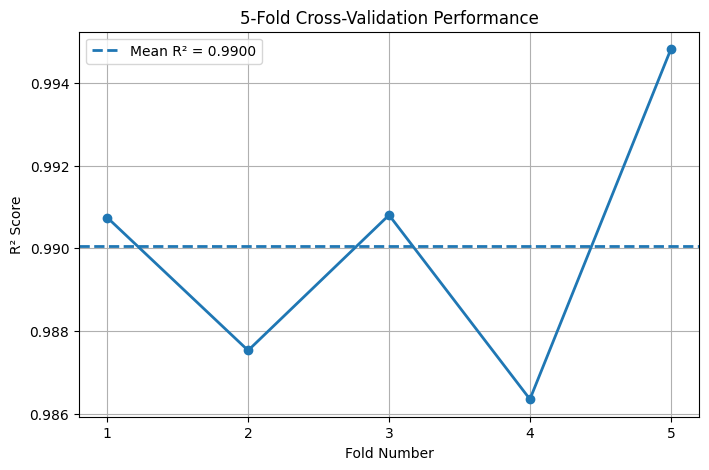

In [25]:
# ============================================================
# STEP 14: VISUALIZE K-FOLD CROSS-VALIDATION SCORES
# ============================================================

fold_numbers = np.arange(1, len(cv_scores) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    fold_numbers,
    cv_scores,
    marker="o",
    linewidth=2
)

# Mean CV score
mean_cv_score = cv_scores.mean()

plt.axhline(
    mean_cv_score,
    linestyle="--",
    linewidth=2,
    label=f"Mean R² = {mean_cv_score:.4f}"
)

plt.title("5-Fold Cross-Validation Performance")
plt.xlabel("Fold Number")
plt.ylabel("R² Score")
plt.xticks(fold_numbers)
plt.legend()
plt.grid(True)

plt.show()

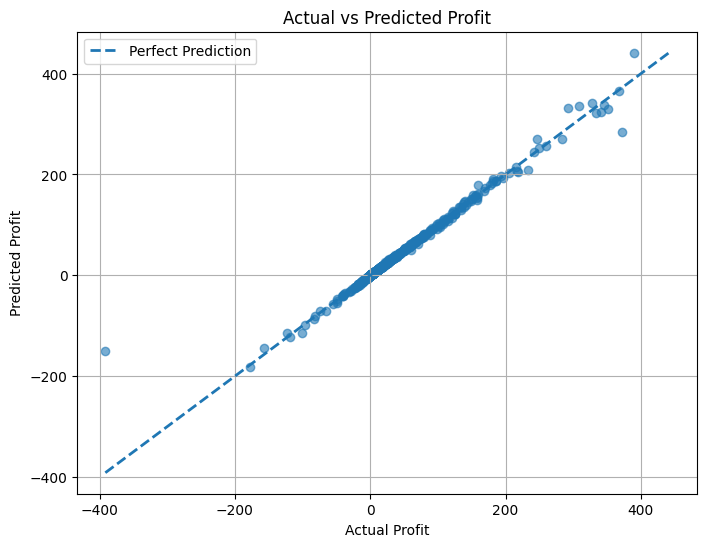

In [26]:
# ============================================================
# STEP 15: ACTUAL VS PREDICTED PROFIT
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

# Perfect prediction reference line
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("Actual vs Predicted Profit")
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profit")
plt.legend()
plt.grid(True)

plt.show()

In [27]:
# ============================================================
# STEP 16: PREDICTION ERROR ANALYSIS
# ============================================================

# Calculate residuals
residuals = y_test.values - y_pred

print("Prediction Error Analysis")
print("=" * 60)

print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Minimum Residual: {residuals.min():.4f}")
print(f"Maximum Residual: {residuals.max():.4f}")

# Create residual DataFrame
error_analysis = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": y_pred,
    "Residual": residuals
})

print("\nFirst 10 prediction errors:")
display(error_analysis.head(10))

Prediction Error Analysis
Mean Residual: -0.1763
Minimum Residual: -240.6457
Maximum Residual: 86.4960

First 10 prediction errors:


,Actual Profit,Predicted Profit,Residual
0,2.87,2.8731,-0.0031
1,-0.63,-0.6098,-0.0202
2,2.16,2.1595,0.0005
3,34.59,34.7879,-0.1979
4,196.80,192.9276,3.8724
5,10.80,11.0789,-0.2789
6,5.94,5.7301,0.2099
7,4.52,4.4174,0.1026
8,-49.11,-47.1320,-1.9780
9,21.61,21.6526,-0.0426


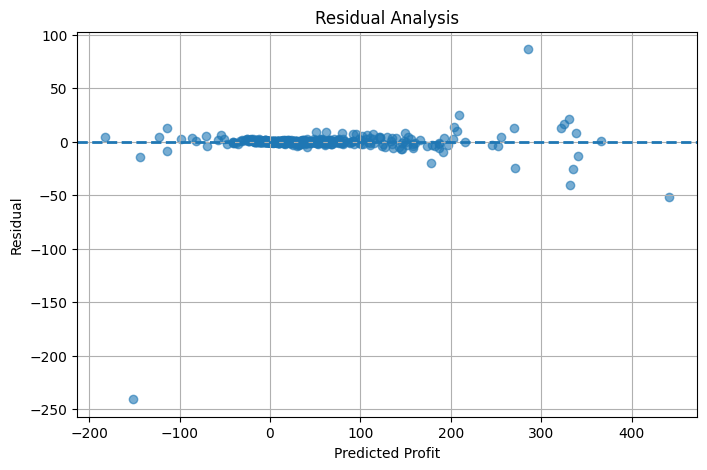

In [28]:
# ============================================================
# RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title("Residual Analysis")
plt.xlabel("Predicted Profit")
plt.ylabel("Residual")
plt.grid(True)

plt.show()

In [29]:
# ============================================================
# STEP 17: PERFORMANCE SUMMARY
# ============================================================

performance_summary = pd.DataFrame({
    "Metric": [
        "Mean CV R²",
        "CV Standard Deviation",
        "Test R²",
        "Test MAE",
        "Test RMSE"
    ],
    "Score": [
        cv_scores.mean(),
        cv_scores.std(),
        r2,
        mae,
        rmse
    ]
})

print("============================================================")
print("CROSS-VALIDATION AND TEST PERFORMANCE SUMMARY")
print("============================================================")

display(performance_summary.round(4))

CROSS-VALIDATION AND TEST PERFORMANCE SUMMARY


,Metric,Score
0,Mean CV R²,0.9900
1,CV Standard Deviation,0.0030
2,Test R²,0.9757
3,Test MAE,1.2752
4,Test RMSE,8.7029


In [30]:
# ============================================================
# STEP 18: FEATURE IMPORTANCE ANALYSIS
# ============================================================

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

# Sort from highest to lowest importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance.round(4))

Feature Importance:


,Feature,Importance
4,Profit_Margin,0.4967
3,Sales,0.4696
2,Discount,0.0302
1,Unit_Price,0.0023
0,Quantity,0.0012


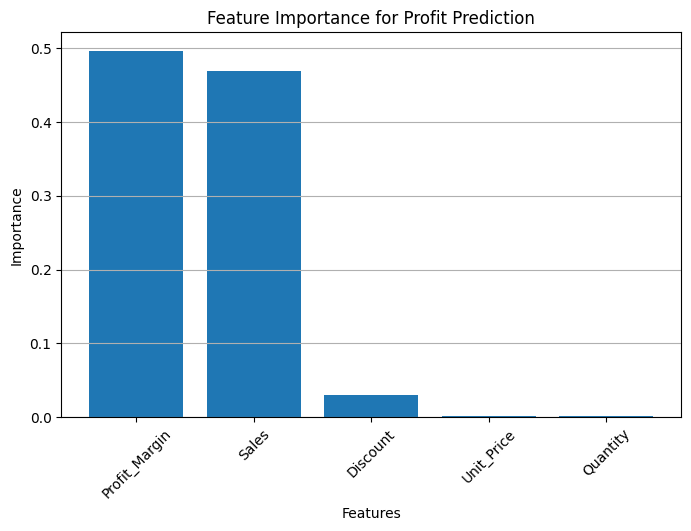

In [31]:
# ============================================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance for Profit Prediction")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

In [32]:
# ============================================================
# STEP 19: SAVE TRAINED MODEL AND SCALER
# ============================================================

import joblib

# Save the trained Random Forest model
joblib.dump(model, "sales_profit_random_forest_model.pkl")

# Save the scaler
joblib.dump(scaler, "sales_profit_scaler.pkl")

print("Model saved successfully!")
print("File: sales_profit_random_forest_model.pkl")

print("\nScaler saved successfully!")
print("File: sales_profit_scaler.pkl")

Model saved successfully!
File: sales_profit_random_forest_model.pkl

Scaler saved successfully!
File: sales_profit_scaler.pkl


In [33]:
# ============================================================
# STEP 20: FINAL CROSS-VALIDATION RESULTS REPORT
# ============================================================

print("=" * 65)
print("       CROSS-VALIDATION TECHNIQUES - FINAL RESULTS")
print("=" * 65)

print("\nDataset:")
print("Sales_Data")

print("\nModel:")
print("Random Forest Regression")

print("\nCross-Validation:")
print("Technique: K-Fold Cross-Validation")
print("Number of Folds:", kfold.n_splits)

print("\n" + "-" * 65)
print("CROSS-VALIDATION SCORES")
print("-" * 65)

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i} R² Score : {score:.4f}")

print(f"\nMean CV R² Score  : {cv_scores.mean():.4f}")
print(f"CV Std. Deviation : {cv_scores.std():.4f}")

print("\n" + "-" * 65)
print("TEST SET PERFORMANCE")
print("-" * 65)

print(f"R² Score          : {r2:.4f}")
print(f"MAE               : {mae:.4f}")
print(f"RMSE              : {rmse:.4f}")

print("\n" + "-" * 65)
print("FEATURES USED")
print("-" * 65)

for feature in features:
    print("-", feature)

print("\n" + "=" * 65)
print("              EXPERIMENT COMPLETED")
print("=" * 65)

       CROSS-VALIDATION TECHNIQUES - FINAL RESULTS

Dataset:
Sales_Data

Model:
Random Forest Regression

Cross-Validation:
Technique: K-Fold Cross-Validation
Number of Folds: 5

-----------------------------------------------------------------
CROSS-VALIDATION SCORES
-----------------------------------------------------------------
Fold 1 R² Score : 0.9907
Fold 2 R² Score : 0.9875
Fold 3 R² Score : 0.9908
Fold 4 R² Score : 0.9863
Fold 5 R² Score : 0.9948

Mean CV R² Score  : 0.9900
CV Std. Deviation : 0.0030

-----------------------------------------------------------------
TEST SET PERFORMANCE
-----------------------------------------------------------------
R² Score          : 0.9757
MAE               : 1.2752
RMSE              : 8.7029

-----------------------------------------------------------------
FEATURES USED
-----------------------------------------------------------------
- Quantity
- Unit_Price
- Discount
- Sales
- Profit_Margin

              EXPERIMENT COMPLETED


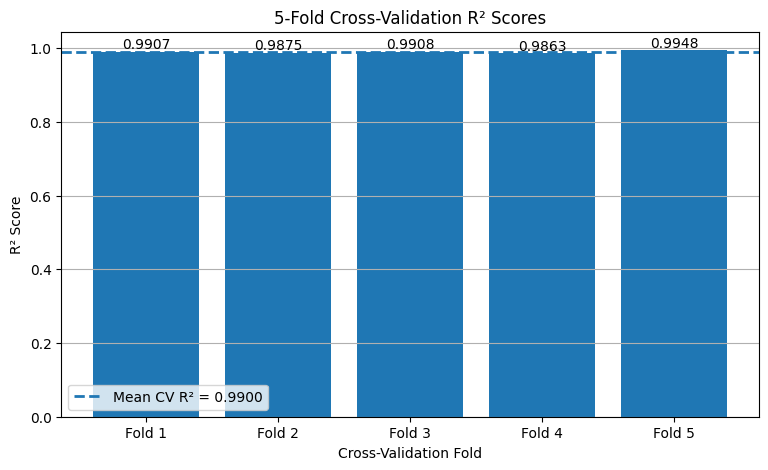

In [34]:
# ============================================================
# STEP 21: FINAL K-FOLD SCORE VISUALIZATION
# ============================================================

plt.figure(figsize=(9, 5))

bars = plt.bar(
    [f"Fold {i}" for i in range(1, len(cv_scores) + 1)],
    cv_scores
)

# Add score values above each bar
for bar, score in zip(bars, cv_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{score:.4f}",
        ha="center",
        va="bottom"
    )

# Mean CV score
plt.axhline(
    cv_scores.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Mean CV R² = {cv_scores.mean():.4f}"
)

plt.title("5-Fold Cross-Validation R² Scores")
plt.xlabel("Cross-Validation Fold")
plt.ylabel("R² Score")
plt.legend()
plt.grid(axis="y")

plt.show()

In [35]:
# ============================================================
# STEP 22: CREATE PROFIT PREDICTION FUNCTION
# ============================================================

def predict_profit(quantity, unit_price, discount, sales, profit_margin):
    """
    Predict profit using the trained Random Forest model.
    """

    # Create input DataFrame with the same feature order
    input_data = pd.DataFrame({
        "Quantity": [quantity],
        "Unit_Price": [unit_price],
        "Discount": [discount],
        "Sales": [sales],
        "Profit_Margin": [profit_margin]
    })

    # Apply the previously fitted scaler
    input_scaled = scaler.transform(input_data)

    # Make prediction
    prediction = model.predict(input_scaled)

    return prediction[0]


print("Profit prediction function created successfully!")

Profit prediction function created successfully!


In [36]:
# ============================================================
# TEST THE PROFIT PREDICTION FUNCTION
# ============================================================

predicted_profit = predict_profit(
    quantity=5,
    unit_price=1000,
    discount=0.10,
    sales=4500,
    profit_margin=0.20
)

print(f"Predicted Profit: {predicted_profit:.2f}")

Predicted Profit: 15.54


In [37]:
# ============================================================
# STEP 23: COMPLETE CROSS-VALIDATION EVALUATION TABLE
# ============================================================

cv_results = pd.DataFrame({
    "Fold": [f"Fold {i}" for i in range(1, len(cv_scores) + 1)],
    "R² Score": cv_scores
})

# Add summary rows
summary_rows = pd.DataFrame({
    "Fold": ["Mean", "Standard Deviation"],
    "R² Score": [cv_scores.mean(), cv_scores.std()]
})

cv_results = pd.concat(
    [cv_results, summary_rows],
    ignore_index=True
)

print("============================================================")
print("5-FOLD CROSS-VALIDATION RESULTS")
print("============================================================")

display(cv_results.round(4))

5-FOLD CROSS-VALIDATION RESULTS


,Fold,R² Score
0,Fold 1,0.9907
1,Fold 2,0.9875
2,Fold 3,0.9908
3,Fold 4,0.9863
4,Fold 5,0.9948
5,Mean,0.9900
6,Standard Deviation,0.0030


In [38]:
# ============================================================
# STEP 24: SAVE CROSS-VALIDATION RESULTS
# ============================================================

# Create final results DataFrame
final_results = pd.DataFrame({
    "Metric": [
        "Fold 1 R²",
        "Fold 2 R²",
        "Fold 3 R²",
        "Fold 4 R²",
        "Fold 5 R²",
        "Mean CV R²",
        "CV Standard Deviation",
        "Test R²",
        "Test MAE",
        "Test RMSE"
    ],
    "Value": [
        cv_scores[0],
        cv_scores[1],
        cv_scores[2],
        cv_scores[3],
        cv_scores[4],
        cv_scores.mean(),
        cv_scores.std(),
        r2,
        mae,
        rmse
    ]
})

# Save to Excel
output_file = "Cross_Validation_Sales_Results.xlsx"

final_results.to_excel(
    output_file,
    index=False
)

print("Results saved successfully!")
print("File:", output_file)

print("\nFinal Results:")
display(final_results.round(4))

Results saved successfully!
File: Cross_Validation_Sales_Results.xlsx

Final Results:


,Metric,Value
0,Fold 1 R²,0.9907
1,Fold 2 R²,0.9875
2,Fold 3 R²,0.9908
3,Fold 4 R²,0.9863
4,Fold 5 R²,0.9948
5,Mean CV R²,0.9900
6,CV Standard Deviation,0.0030
7,Test R²,0.9757
8,Test MAE,1.2752
9,Test RMSE,8.7029


In [39]:
# ============================================================
# STEP 25: DOWNLOAD PROJECT OUTPUT FILES
# ============================================================

from google.colab import files

files.download("Cross_Validation_Sales_Results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
files.download("sales_profit_random_forest_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
files.download("sales_profit_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
# ============================================================
# STEP 26: FINAL PROJECT VERIFICATION
# ============================================================

import os

print("=" * 65)
print("       CROSS-VALIDATION PROJECT VERIFICATION")
print("=" * 65)

# Dataset
print("\n[1] Dataset")
print("Dataset shape:", df.shape)
print("Features used:", features)
print("Target:", "Profit")

# Train/Test
print("\n[2] Train-Test Split")
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

# Model
print("\n[3] Model")
print("Random Forest Regressor")
print("Number of trees:", model.n_estimators)

# Cross-validation
print("\n[4] K-Fold Cross-Validation")
print("Number of folds:", kfold.n_splits)

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i} R²: {score:.4f}")

print(f"Mean CV R²: {cv_scores.mean():.4f}")
print(f"CV Std. Dev.: {cv_scores.std():.4f}")

# Test performance
print("\n[5] Test Performance")
print(f"Test R² : {r2:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")

# Saved files
print("\n[6] Saved Files")

project_files = [
    "Cross_Validation_Sales_Results.xlsx",
    "sales_profit_random_forest_model.pkl",
    "sales_profit_scaler.pkl"
]

for file in project_files:
    if os.path.exists(file):
        print("✓", file)
    else:
        print("✗", file)

print("\n" + "=" * 65)
print("       PROJECT IMPLEMENTATION COMPLETED")
print("=" * 65)

       CROSS-VALIDATION PROJECT VERIFICATION

[1] Dataset
Dataset shape: (5000, 22)
Features used: ['Quantity', 'Unit_Price', 'Discount', 'Sales', 'Profit_Margin']
Target: Profit

[2] Train-Test Split
Training samples: 4000
Testing samples : 1000

[3] Model
Random Forest Regressor
Number of trees: 100

[4] K-Fold Cross-Validation
Number of folds: 5
Fold 1 R²: 0.9907
Fold 2 R²: 0.9875
Fold 3 R²: 0.9908
Fold 4 R²: 0.9863
Fold 5 R²: 0.9948
Mean CV R²: 0.9900
CV Std. Dev.: 0.0030

[5] Test Performance
Test R² : 0.9757
Test MAE: 1.2752
Test RMSE: 8.7029

[6] Saved Files
✓ Cross_Validation_Sales_Results.xlsx
✓ sales_profit_random_forest_model.pkl
✓ sales_profit_scaler.pkl

       PROJECT IMPLEMENTATION COMPLETED
